In [1]:
pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
iranian_churn = fetch_ucirepo(id=563)

# data (as pandas dataframes)
X_reg = iranian_churn.data.features
y_reg = iranian_churn.data.targets

# metadata
print(iranian_churn.metadata)

# variable information
print(iranian_churn.variables)


{'uci_id': 563, 'name': 'Iranian Churn', 'repository_url': 'https://archive.ics.uci.edu/dataset/563/iranian+churn+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/563/data.csv', 'abstract': "This dataset is randomly collected from an Iranian telecom company's database over a period of 12 months.", 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 3150, 'num_features': 13, 'feature_types': ['Integer'], 'demographics': ['Age'], 'target_col': ['Churn'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2020, 'last_updated': 'Sat Mar 09 2024', 'dataset_doi': '10.24432/C5JW3Z', 'creators': [], 'intro_paper': None, 'additional_info': {'summary': 'This dataset is randomly collected from an Iranian telecom companyâ€™s database over a period of 12 months. A total of 3150 rows of data, each representing a customer, bear information for 13 columns. The attribu

In [3]:
import random
import platform
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")

SEED=42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid",context ="notebook")
plt.rcParams["figure.figsize"]=(7,4)
plt.rcParams["figure.dpi"] = 110


print(f"python: {sys.version.split()[0]}")
print(f"Platform:{platform.platform()}")
print(f"seaborn: {sns.__version__}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"sklearn: {sklearn.__version__}")

python: 3.13.15
Platform:Linux-6.6.122+-x86_64-with-glibc2.39
seaborn: 0.13.2
pandas: 2.2.3
numpy: 2.1.3
sklearn: 1.6.1


In [4]:
print(y_reg)
X_reg.head()

      Churn
0         0
1         0
2         0
3         0
4         0
...     ...
3145      0
3146      0
3147      0
3148      0
3149      1

[3150 rows x 1 columns]


,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805


In [5]:
X_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            3150 non-null   int64  
 1   Complains                3150 non-null   int64  
 2   Subscription  Length     3150 non-null   int64  
 3   Charge  Amount           3150 non-null   int64  
 4   Seconds of Use           3150 non-null   int64  
 5   Frequency of use         3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
 7   Distinct Called Numbers  3150 non-null   int64  
 8   Age Group                3150 non-null   int64  
 9   Tariff Plan              3150 non-null   int64  
 10  Status                   3150 non-null   int64  
 11  Age                      3150 non-null   int64  
 12  Customer Value           3150 non-null   float64
dtypes: float64(1), int64(12)
memory usage: 320.1 KB


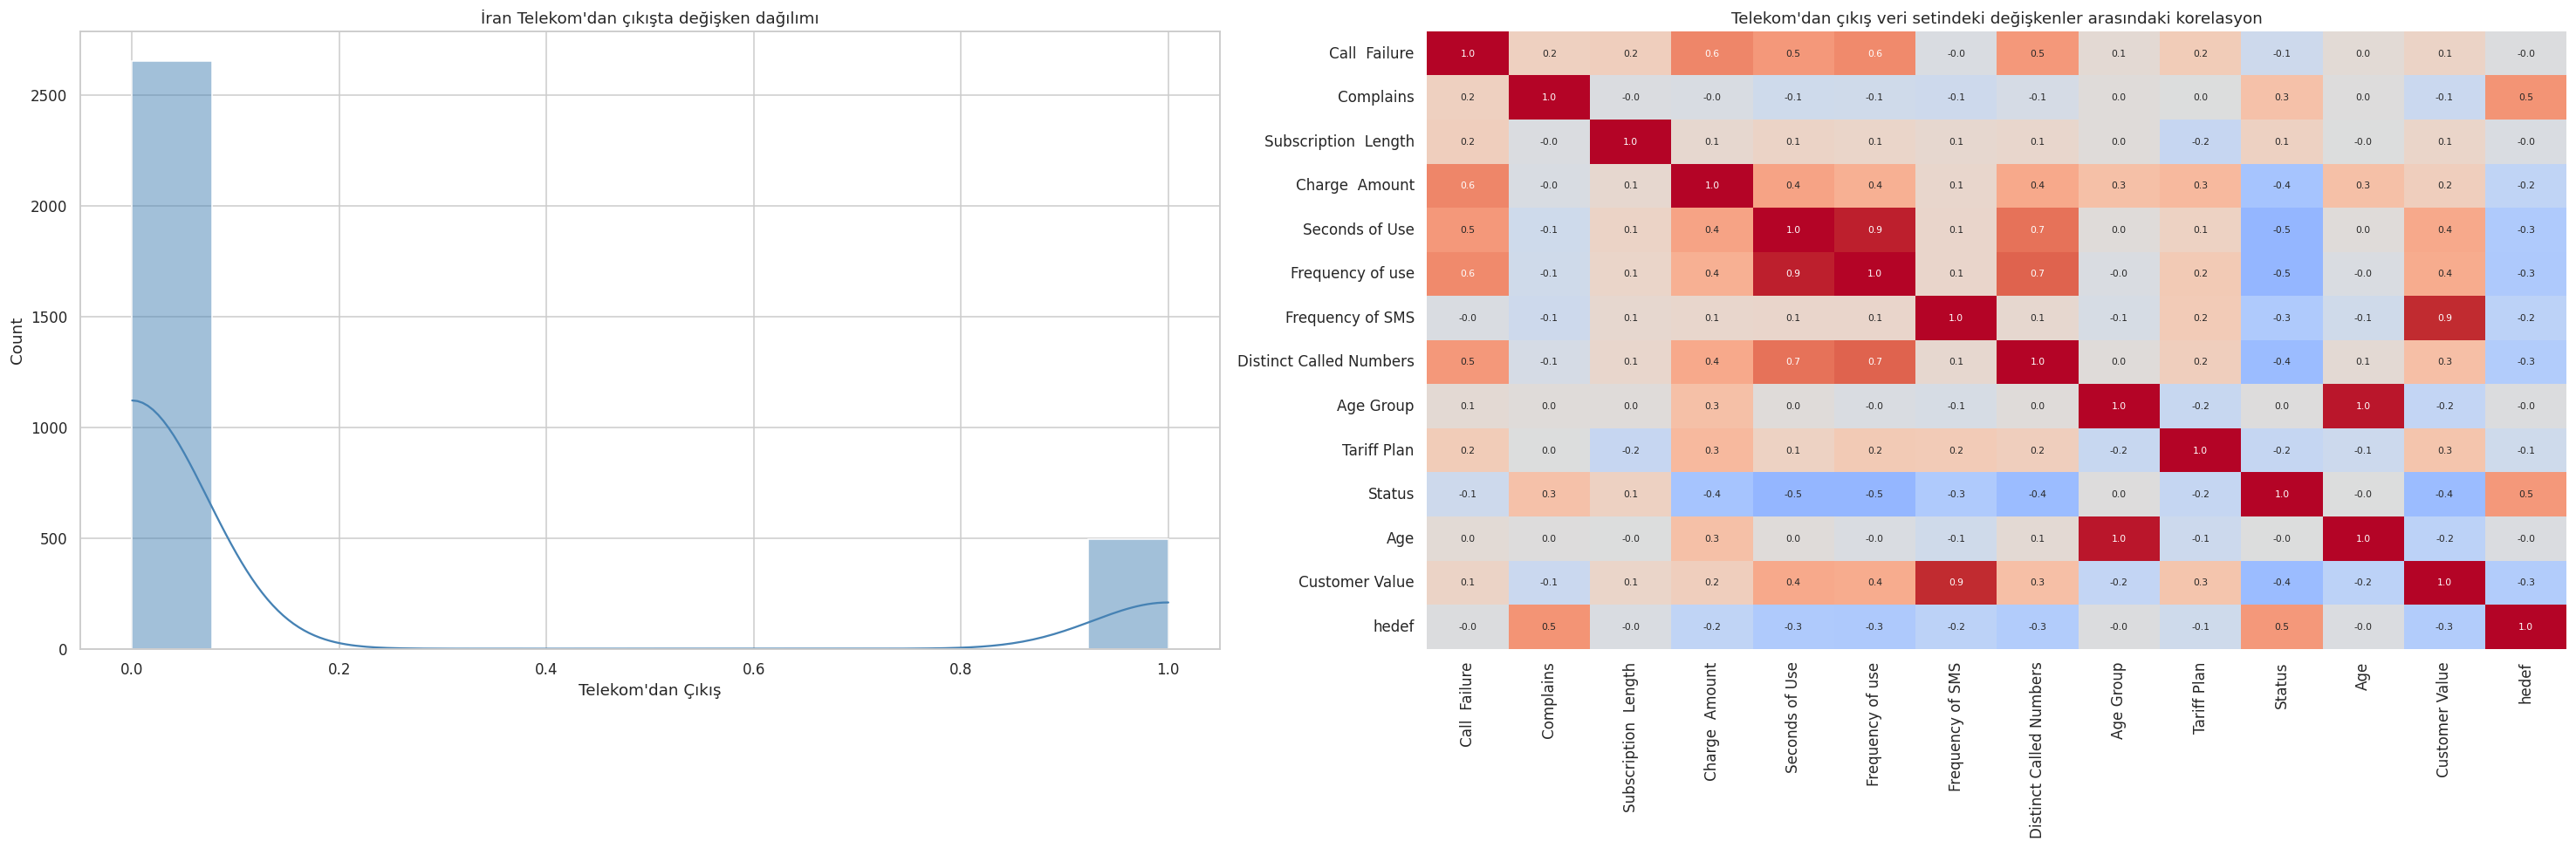

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(27, 9))

# 1. Grafik: Histogram (.squeeze() ile tek boyuta indirgendi)
sns.histplot(y_reg.squeeze(), kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("İran Telekom'dan çıkışta değişken dağılımı")
axes[0].set_xlabel("Telekom'dan Çıkış")

# 2. Grafik: Korelasyon matrisi (.squeeze().rename() ile seri yapılıp adlandırıldı)
y_series = y_reg.squeeze().rename("hedef")
corr = pd.concat([X_reg, y_series], axis=1).corr()

sns.heatmap(corr, annot=True, fmt=".1f", cmap="coolwarm", center=0,
            ax=axes[1], cbar=False, annot_kws={"size": 7})
axes[1].set_title("Telekom'dan çıkış veri setindeki değişkenler arasındaki korelasyon")

plt.tight_layout()
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
Xr_train,Xr_test,yr_train,yr_test=train_test_split(X_reg,y_reg,test_size=0.2,random_state=SEED)

In [8]:
print(f"{Xr_train.shape[0]}")
Xr_test.shape[0]

2520


630

#**Baseline & Linear**

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.dummy import DummyRegressor
baseline = DummyRegressor(strategy="mean").fit(Xr_train,yr_train)

linear = LinearRegression().fit(Xr_train,yr_train)

def regresyon_raporu (model,X, y,ad):
  tahmin=model.predict(X)
  return{
     "Model" :ad,
     "Mae"   : mean_absolute_error(y,tahmin),
     "mse"   : mean_squared_error(y,tahmin),
     "rmse"  : np.sqrt(mean_squared_error(y,tahmin)),
     "r2"    : r2_score(y,tahmin)
    }
sonuc = pd.DataFrame([
    regresyon_raporu(baseline,Xr_train,yr_train,"Baseline"),
    regresyon_raporu(linear,Xr_test,yr_test,"Linear")
]).set_index("Model").round(3)
sonuc

,Mae,mse,rmse,r2
Model,,,,
Baseline,0.259,0.129,0.360,0.000
Linear,0.184,0.089,0.299,0.381


#**Yorum**
- Hedefteki değişkenliğin yaklaşık %38'i eldeki özelliklerle açıklanabiliyor
- RMSE'den yola çıkarak İyileşme Oranı = %28,96~ değerindedir
- MAE'den yola çıkarak İyileşme Oranı = %16,94~ değerindedir

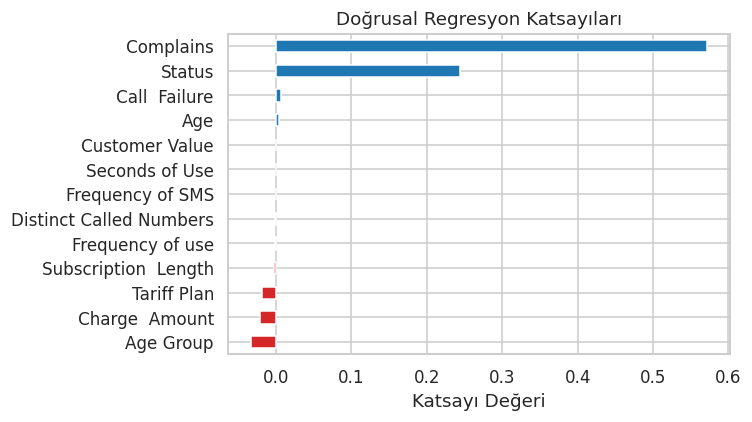

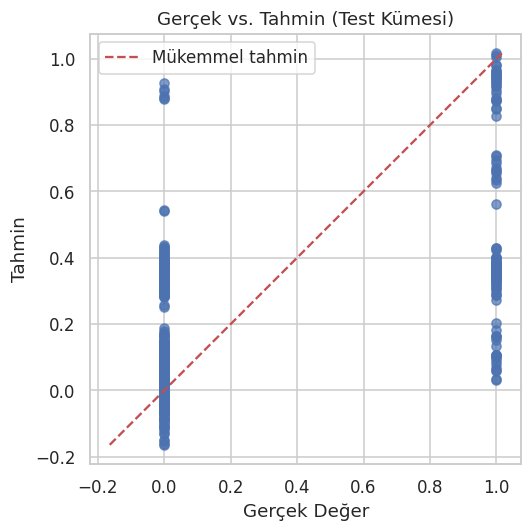

In [10]:
# 1. Grafik: Katsayılar (linear.coef_.ravel() ile 1 boyuta indirgendi)
katsayilar = pd.Series(linear.coef_.ravel(), index=X_reg.columns).sort_values()

plt.figure(figsize=(7, 4))
katsayilar.plot(kind="barh", color=np.where(katsayilar > 0, "tab:blue", "tab:red"))
plt.title("Doğrusal Regresyon Katsayıları")
plt.xlabel("Katsayı Değeri")
plt.tight_layout()
plt.show()


# 2. Grafik: Gerçek vs. Tahmin
tahmin = linear.predict(Xr_test).ravel()
yr_test_arr = np.array(yr_test).ravel()

plt.figure(figsize=(5, 5))
plt.scatter(yr_test_arr, tahmin, alpha=0.7)

# Eksen sınırları
min_val = min(yr_test_arr.min(), tahmin.min())
max_val = max(yr_test_arr.max(), tahmin.max())
lim = [min_val, max_val]

plt.plot(lim, lim, "r--", label="Mükemmel tahmin")
plt.xlabel("Gerçek Değer")
plt.ylabel("Tahmin")
plt.title("Gerçek vs. Tahmin (Test Kümesi)")
plt.legend()
plt.tight_layout()
plt.show()

##**Yorum**
- Model ayırt edici sinyalleri (örn complains) başarıyla öğrenmiştir.
- Bazı tahminler olasılık sınırlarını ([0,1] aralığını) aşmaktadır. Bu durum Linear Regresyon yerine Lojistik Regresyon kullanılması gerektiğini göstermektedir. Birazdan uygulayacağımız Lojistik Regresyon, modelin tahminlerini olasılık sınırları çerçevesinde tutacaktır.

#**Ridge & Lasso**

In [11]:
from sklearn.linear_model import Ridge,Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

modeller= {
    "Doğrusal": make_pipeline(StandardScaler(),LinearRegression()),
    "Ridge": make_pipeline(StandardScaler(),Ridge(alpha=1.0)),
    "Lasso": make_pipeline(StandardScaler(),Lasso(alpha=1.0))
}

satirlar =[]

for ad,m in modeller.items():
  m.fit(Xr_train,yr_train)
  satirlar.append(regresyon_raporu(m,Xr_test,yr_test,ad))

pd.DataFrame(satirlar).set_index("Model").round(3)

,Mae,mse,rmse,r2
Model,,,,
Doğrusal,0.184,0.089,0.299,0.381
Ridge,0.184,0.089,0.299,0.381
Lasso,0.274,0.145,0.380,-0.003


Lasso'nun r2'si negatif geldi, alpha'yı değiştireceğiz. İdeal alpha için;

In [12]:
from sklearn.linear_model import LassoCV

modeller = {
    "Doğrusal": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge":    make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "LassoCV":  make_pipeline(StandardScaler(), LassoCV(alphas=np.logspace(-4, 0, 50), cv=5))
}

satirlar = []
y_train_1d = np.ravel(yr_train)

for ad, m in modeller.items():
    m.fit(Xr_train, y_train_1d)
    satirlar.append(regresyon_raporu(m, Xr_test, yr_test, ad))

pd.DataFrame(satirlar).set_index("Model").round(3)

,Mae,mse,rmse,r2
Model,,,,
Doğrusal,0.184,0.089,0.299,0.381
Ridge,0.184,0.089,0.299,0.381
LassoCV,0.183,0.089,0.299,0.381


##**Yorum**
- R2'ler eşit geldi:
- Bu durum Linear Modelin ezberlemediğini yani overfitting olmadığını gösteriyor. Ridge ve Lasso'nun amacı overfitting'i engellemektir.
- Çoklu doğrusal bağlantı (Multicolinearity) yoktur. Ridge modeli, Linear Modelde bu hata varsa düzeltmek üzere tasarlanmıştır, R2'leri aynı çıktığı için Linear Modelde de Multicolinearity olmadığı sonucuna varırız.
- Lasso çapraz doğrulama ile hata oranını düşürmeye çalışmış fakat gerek bulamamış ve alpha'yı 0'a çok yakın seçmiştir. Bu, veri setindeki 13 değişkenin gürültü yaratmadığı ve katsayılarının sıfırlanmasının gerekmediği anlamına gelmektedir.
- Eldeki değişkenlerle kurulabilecek en iyi Linear Model budur. Geri kalan %61.9'luk açıklanamayan varyansı açıklamak için doğrusal olmayan (ağaç tabanlı veya polinomiyal) ilişkileri modellemek gerekir.

In [13]:
lasso= modeller["LassoCV"].named_steps["lassocv"]
pd.Series(lasso.coef_,index=X_reg.columns).round(2).to_frame("Lasso değişkenler").T

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value
Lasso değişkenler,0.05,0.15,-0.02,-0.03,0.05,-0.1,-0.04,-0.03,-0.03,-0.0,0.1,0.02,0.02


In [14]:
print(modeller.keys())

dict_keys(['Doğrusal', 'Ridge', 'LassoCV'])


In [15]:
X_clf, y_clf = X_reg, y_reg
y_clf.tail(2)

,Churn
3148,0
3149,1


In [16]:
print("Sınıf dağılımı(0=Memnun, 1= Terk Etti):")
print(y_clf.value_counts().rename({0:"Memnun",1:"Terk Etti"}))
X_clf.iloc[:,:6].describe().T.round(2)

Sınıf dağılımı(0=Memnun, 1= Terk Etti):
Churn    
Memnun       2655
Terk Etti     495
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
Call Failure,3150.0,7.63,7.26,0.0,1.00,6.0,12.00,36.0
Complains,3150.0,0.08,0.27,0.0,0.00,0.0,0.00,1.0
Subscription Length,3150.0,32.54,8.57,3.0,30.00,35.0,38.00,47.0
Charge Amount,3150.0,0.94,1.52,0.0,0.00,0.0,1.00,10.0
Seconds of Use,3150.0,4472.46,4197.91,0.0,1391.25,2990.0,6478.25,17090.0
Frequency of use,3150.0,69.46,57.41,0.0,27.00,54.0,95.00,255.0


In [17]:
Xc_train,Xc_test,yc_train,yc_test=train_test_split(X_clf,y_clf,test_size=0.2,random_state=SEED)

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

siniflandiricilar = {
    "Baseline": DummyClassifier(strategy="most_frequent").fit(Xc_train,yc_train),
    "Logistic": LogisticRegression().fit(Xc_train,yc_train),
    "KNN": KNeighborsClassifier().fit(Xc_train,yc_train),
    "Karar ağacı": DecisionTreeClassifier().fit(Xc_train,yc_train),
    "Rastgele orman": RandomForestClassifier().fit(Xc_train,yc_train)
}


satirlar =[]

for ad,m in siniflandiricilar.items():
  m.fit(Xc_train,yc_train)
  satirlar.append(
      {
          "Model": ad,
          "Eğitim" : accuracy_score(yc_train,m.predict(Xc_train)),
          "Test": accuracy_score(yc_test,m.predict(Xc_test))
      }
  )

pd.DataFrame(satirlar).set_index("Model").round(3)

,Eğitim,Test
Model,,
Baseline,0.847,0.825
Logistic,0.856,0.825
KNN,0.902,0.837
Karar ağacı,0.994,0.933
Rastgele orman,0.994,0.937


##**Yorum**
- Baseline Model'in test sonuçları referans olarak kullanılacaktır. Bütün verilere churn=0 tahmininde bulunmuştur.
- Logistic Model başarısız olmuştur. Ölçeklendirme olmaması büyük bir etmendir. Seconds of Use değişkeninin 17000'e kadar çıkması ama 0-1 aralığındaki Complains kadar etkili olmaması ama etkileri ölçeklendirilmemiştir.
- KNN bir miktar churn = 1 kişiyi bulsa da hala ölçek sorunu sebebiyle başarısızdır.
- Karar ağacı ölçek sorunundan etkilenmemiş ve başarısız bir model ortaya koymuştur. Doğrusal olmayan etkileşimleri (örneğin: "Kullanım süresi düşen VE şikayette bulunan müşteri ayrılır") kural tabanlı olarak mükemmel yakalar.
- Random Forest Modeli ise birçok karar ağacını birleştirdiği için en başarılı modeldir.

***Overfitting?***
- En yüksek başarılı modellerimizin (Karar Ağacı ve Random Forest) eğitim başarısı %99.4 iken test başarısı sırasıyla %93.3 ve %93.7 olmuştur. Bu durum modellerin ezberlemediğini göstermektedir. Overfitting **yoktur.**

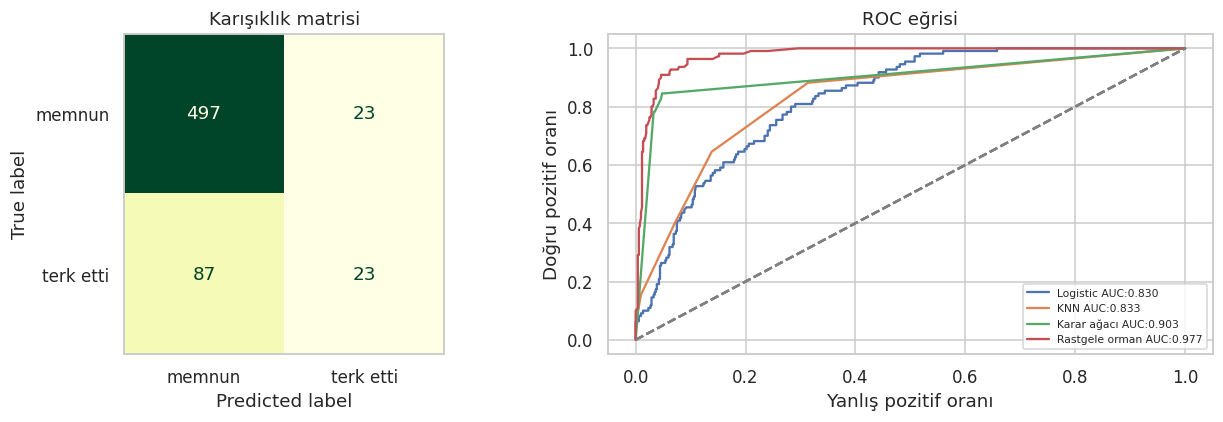

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay ,classification_report, roc_curve, roc_auc_score

model = siniflandiricilar["Logistic"]
tahmin = model.predict(Xc_test)
olasilik = model.predict_proba(Xc_test)[:,1]

fig ,axes = plt.subplots(1,2,figsize=(12,4))

cm = confusion_matrix(yc_test,tahmin)
ConfusionMatrixDisplay.from_predictions(yc_test,tahmin, display_labels =["memnun","terk etti"], cmap="YlGn",ax=axes[0],colorbar=False)
axes[0].set_title("Karışıklık matrisi")
axes[0].grid(False)


for ad in ["Logistic","KNN","Karar ağacı","Rastgele orman"]:
  p=siniflandiricilar[ad].predict_proba(Xc_test)[:,1]
  fpr,tpr,_=roc_curve(yc_test,p)
  axes[1].plot(fpr,tpr,label=f"{ad} AUC:{roc_auc_score(yc_test,p):.3f}")
  axes[1].plot([0,1],[0,1],linestyle="--",color="gray")
  axes[1].set_xlabel("Yanlış pozitif oranı")
  axes[1].set_ylabel("Doğru pozitif oranı")
  axes[1].set_title("ROC eğrisi")
  axes[1].legend(fontsize=7)
  axes[1].grid(True)

plt.tight_layout()
plt.show()

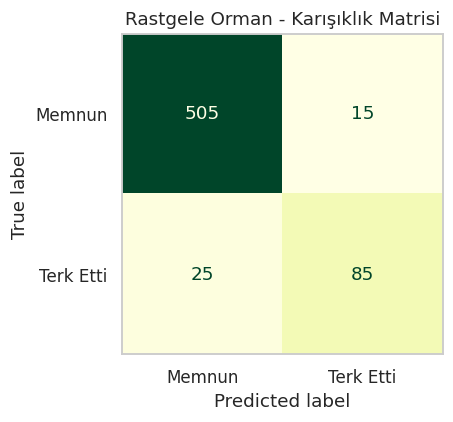

In [20]:
# Rastgele Orman modelini sözlükten çağırıp test tahminlerini alıyoruz
rf_model = siniflandiricilar["Rastgele orman"]
rf_tahmin = rf_model.predict(Xc_test)

# Karışıklık matrisinin çizdirilmesi
fig, ax = plt.subplots(figsize=(5, 4))

ConfusionMatrixDisplay.from_predictions(
    yc_test,
    rf_tahmin,
    display_labels=["Memnun", "Terk Etti"],
    cmap="YlGn",
    colorbar=False,
    ax=ax
)
ax.set_title("Rastgele Orman - Karışıklık Matrisi")
ax.grid(False)

plt.tight_layout()
plt.show()


##**Yorum**
- Churn = 1 : Terk Etti (pozitiftir)
- İlk sol grafik lojistik regresyon testindeki False Negatif oranın pozitif True Label'lı değerler arasında popüler olduğunu yani modelin Pozitif Churn'ı ayırt etmede sorunlu olduğunu (ki linear model ile çok benzer) görüyoruz. Terk edenleri yakalaya**mama** oranı %79.1'dir.
- İlk sağ grafikte bütün modellerin False Pozitif ve True Pozitif oranlarını görüyoruz. (Kesikli Çizgi y=x doğrusu)
- Rastgele Orman %97.7 doğruluk oranıyla en isabetli modeldir
- Karar Ağacı basamaklı karar alma sistemini grafiğe de taşımıştır, %90.3 doğruluk oranı.
- KNN ve Lojistik Modellerin başarısızlığı genel grafikte de kanıtlanmıştır.

In [21]:
from sklearn.model_selection import StratifiedKFold,cross_val_score

In [22]:
cv = StratifiedKFold(n_splits=5, shuffle =True, random_state=SEED)

satirlar =[]

for ad, m in siniflandiricilar.items():
  skorlar=cross_val_score(m,Xc_train,yc_train,cv=cv,scoring="roc_auc")
  satirlar.append({"Model":ad,"Ortalama skor":skorlar.mean(),"Standart sapma":skorlar.std()})

cv_sonuc= pd.DataFrame(satirlar).set_index("Model").sort_values("Ortalama skor",ascending=False).round(3)
display(cv_sonuc)

,Ortalama skor,Standart sapma
Model,,
Rastgele orman,0.983,0.002
Karar ağacı,0.901,0.016
Logistic,0.878,0.005
KNN,0.804,0.017
Baseline,0.500,0.000


- Bu test veriyi 5 parçaya bölüp modelleri test ederek kararlılık analizi yapmıştır.
- Yüksek kararsızlığa sahip bir modelimiz yok, overfitting veya aşırı duyarlılık riski yok.
- Çok kararlı olan iki modelimiz var: Rastgele Orman ve Logistic

In [23]:
from sklearn.model_selection import GridSearchCV

pipe = make_pipeline(StandardScaler(),KNeighborsClassifier())

param_grid = {
    "kneighborsclassifier__n_neighbors":[1,3,5,7,9,11,15,21],
    "kneighborsclassifier__weights":["uniform","distance"]
}

opt =GridSearchCV(pipe,param_grid,cv=cv,scoring="accuracy",n_jobs=-1)
opt.fit(Xc_train,yc_train)

print("best parametre:", opt.best_params_)
print(f"en iyi cv:{opt.best_score_:3f}")


best parametre: {'kneighborsclassifier__n_neighbors': 3, 'kneighborsclassifier__weights': 'distance'}
en iyi cv:0.952778


- Doğru parametreler ve ölçeklendirme sayesinde KNN modeli %95.2 doğruluğa ulaştı.

In [24]:
scaler_dogru = StandardScaler().fit(Xc_train)
Xc_tr= scaler_dogru.transform(Xc_train)
Xc_te= scaler_dogru.transform(Xc_test)

In [25]:
scaler_yanlis= StandardScaler().fit(X_clf)
Xc_tr= scaler_yanlis.transform(Xc_train)
Xc_te= scaler_yanlis.transform(Xc_test)

In [26]:
print("yanlış yöntem " ,scaler_yanlis.mean_[:3].round(2))
print("doğru yöntem" ,scaler_dogru.mean_[:3].round(2))

yanlış yöntem  [ 7.63  0.08 32.54]
doğru yöntem [ 7.68  0.08 32.51]


- Yanlış yöntem eğitim verisi olarak veri setini aldığından veri setinin (3150 veri) ortalamasını verir ve **data** **leakage** yaratır.
- Doğru Yöntem eğitim verisi olarak 2100~ veri kullanır. Gerisi test için kullanılacktır
- Ekrana gelen sayılar arasındaki minik farklar, yanlış yöntemin test verisini içine katarak ortalamayı nasıl kaydırdığını somut olarak görmenizi sağlar.
- Aralarındaki syntax farkı; Doğru: X_train, Yanlış: X_clf

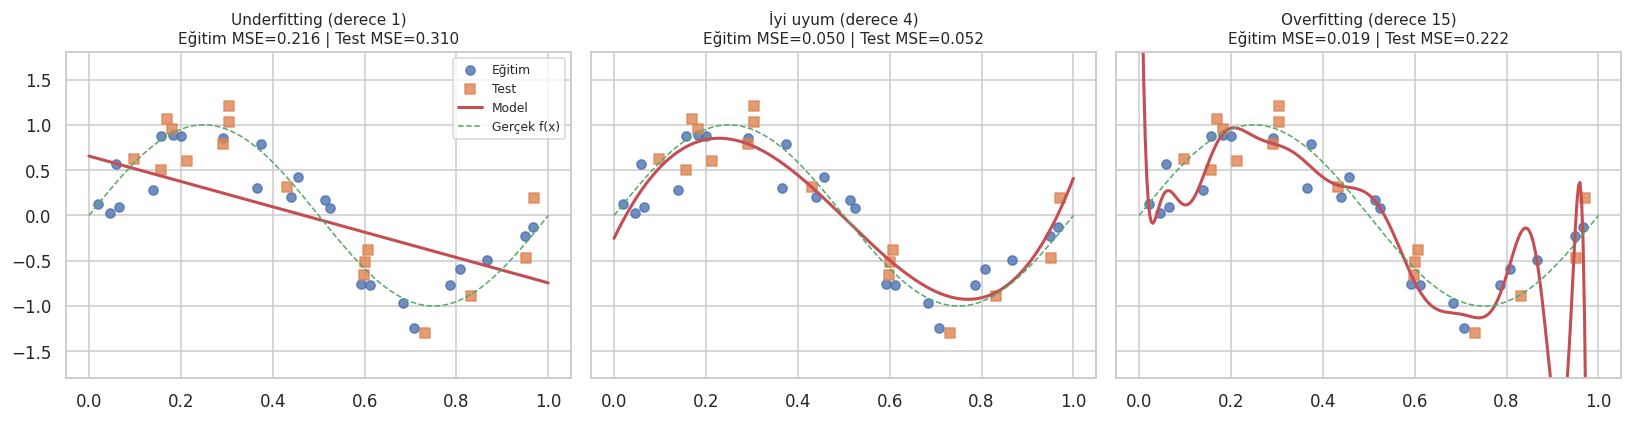

In [27]:
from sklearn.preprocessing import PolynomialFeatures

rng = np.random.RandomState(SEED)
n = 40
x = np.sort(rng.uniform(0, 1, n))
y = np.sin(2 * np.pi * x) + rng.normal(0, 0.25, n)  # gerçek fonksiyon + gürültü

x_tr, x_te, y_tr, y_te = train_test_split(x.reshape(-1, 1), y, test_size=0.4, random_state=SEED)

xs = np.linspace(0, 1, 300).reshape(-1, 1)
dereceler = [1, 4, 15]
basliklar = ["Underfitting (derece 1)", "İyi uyum (derece 4)", "Overfitting (derece 15)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, d, b in zip(axes, dereceler, basliklar):
    model = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
    model.fit(x_tr, y_tr)
    tr_hata = mean_squared_error(y_tr, model.predict(x_tr))
    te_hata = mean_squared_error(y_te, model.predict(x_te))
    ax.scatter(x_tr, y_tr, label="Eğitim", alpha=0.8)
    ax.scatter(x_te, y_te, label="Test", alpha=0.8, marker="s")
    ax.plot(xs, model.predict(xs), "r-", lw=2, label="Model")
    ax.plot(xs, np.sin(2 * np.pi * xs), "g--", lw=1, label="Gerçek f(x)")
    ax.set_ylim(-1.8, 1.8)
    ax.set_title(f"{b}\nEğitim MSE={tr_hata:.3f} | Test MSE={te_hata:.3f}", fontsize=10)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

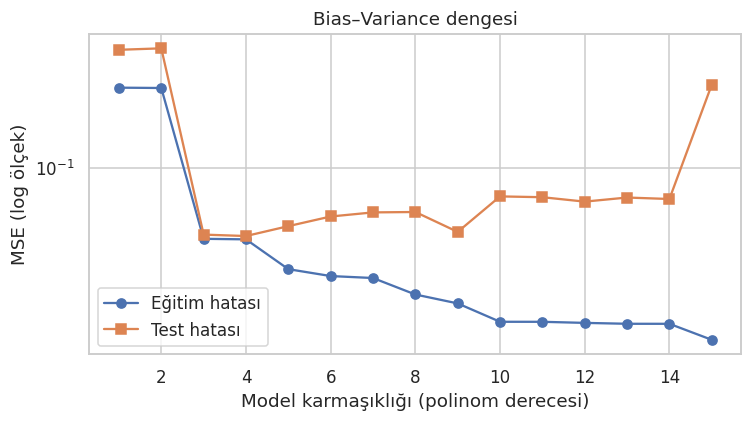

Test hatasının en düşük olduğu derece: 4


In [28]:

# Model karmaşıklığı arttıkça eğitim ve test hatası nasıl değişir?
derece_araligi = range(1, 16)
egitim_hatalari, test_hatalari = [], []

for d in derece_araligi:
    model = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
    model.fit(x_tr, y_tr)
    egitim_hatalari.append(mean_squared_error(y_tr, model.predict(x_tr)))
    test_hatalari.append(mean_squared_error(y_te, model.predict(x_te)))

plt.figure(figsize=(7, 4))
plt.plot(derece_araligi, egitim_hatalari, "o-", label="Eğitim hatası")
plt.plot(derece_araligi, test_hatalari, "s-", label="Test hatası")
plt.yscale("log")
plt.xlabel("Model karmaşıklığı (polinom derecesi)")
plt.ylabel("MSE (log ölçek)")
plt.title("Bias–Variance dengesi")
plt.legend()
plt.tight_layout()
plt.show()

en_iyi = list(derece_araligi)[int(np.argmin(test_hatalari))]
print(f"Test hatasının en düşük olduğu derece: {en_iyi}")

# **K Means**
- Rastgele K merkezi seçilecek
- Her örnek en yakın zamanda atanacak
- Merkezleri atanan örneklerin ortalaması olacak
- Atamalar değişene kadar 2-3 kez tekrarlanacak

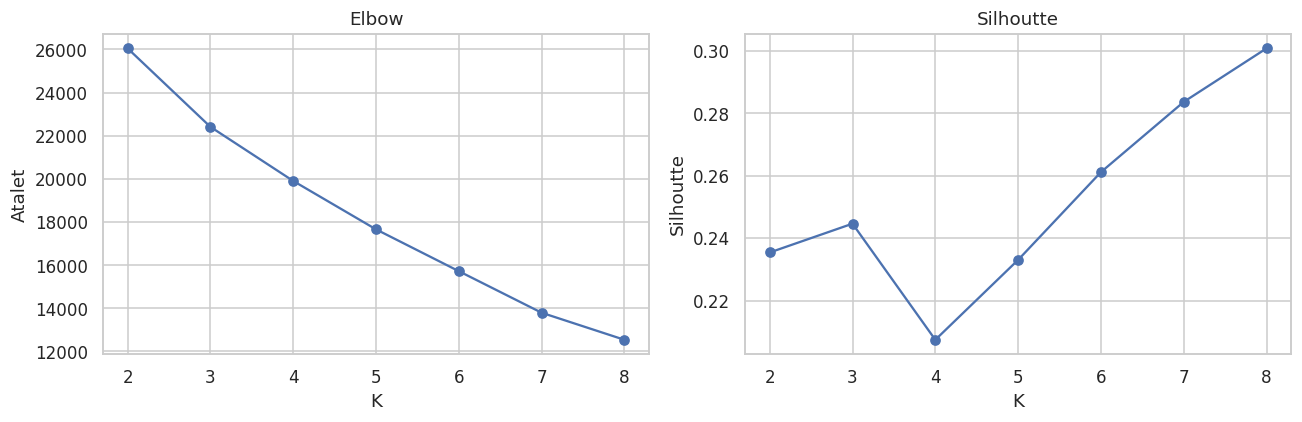

In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

k_degerleri = range(2,9)
atalet, silhoutte= [],[]

for k in k_degerleri:
  km=KMeans(n_clusters=k, n_init=10,random_state=SEED).fit(Xc_tr)
  atalet.append(km.inertia_)
  silhoutte.append(silhouette_score(Xc_tr,km.labels_))


fig, axes =plt.subplots(1,2,figsize=(12,4))

axes[0].plot(k_degerleri,atalet,marker="o")
axes[0].set_title("Elbow")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Atalet")

axes[1].plot(k_degerleri,silhoutte,marker="o")
axes[1].set_title("Silhoutte")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhoutte")

plt.tight_layout()
plt.show()